In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

### EDA - Exploratory Data Analysis

In [2]:
df = sns.load_dataset("diamonds")
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   carat    53940 non-null  float64 
 1   cut      53940 non-null  category
 2   color    53940 non-null  category
 3   clarity  53940 non-null  category
 4   depth    53940 non-null  float64 
 5   table    53940 non-null  float64 
 6   price    53940 non-null  int64   
 7   x        53940 non-null  float64 
 8   y        53940 non-null  float64 
 9   z        53940 non-null  float64 
dtypes: category(3), float64(6), int64(1)
memory usage: 3.0 MB


In [4]:
df.describe()

,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


In [5]:
df_weird = df[(df['x']==0)|(df['y']==0)|(df['z']==0)]
print(df_weird.shape[0]/df.shape[0])
df_weird

0.0003707823507601038


,carat,cut,color,clarity,depth,table,price,x,y,z
2207,1.00,Premium,G,SI2,59.1,59.0,3142,6.55,6.48,0.0
2314,1.01,Premium,H,I1,58.1,59.0,3167,6.66,6.60,0.0
4791,1.10,Premium,G,SI2,63.0,59.0,3696,6.50,6.47,0.0
5471,1.01,Premium,F,SI2,59.2,58.0,3837,6.50,6.47,0.0
10167,1.50,Good,G,I1,64.0,61.0,4731,7.15,7.04,0.0
11182,1.07,Ideal,F,SI2,61.6,56.0,4954,0.00,6.62,0.0
11963,1.00,Very Good,H,VS2,63.3,53.0,5139,0.00,0.00,0.0
13601,1.15,Ideal,G,VS2,59.2,56.0,5564,6.88,6.83,0.0
15951,1.14,Fair,G,VS1,57.5,67.0,6381,0.00,0.00,0.0
24394,2.18,Premium,H,SI2,59.4,61.0,12631,8.49,8.45,0.0


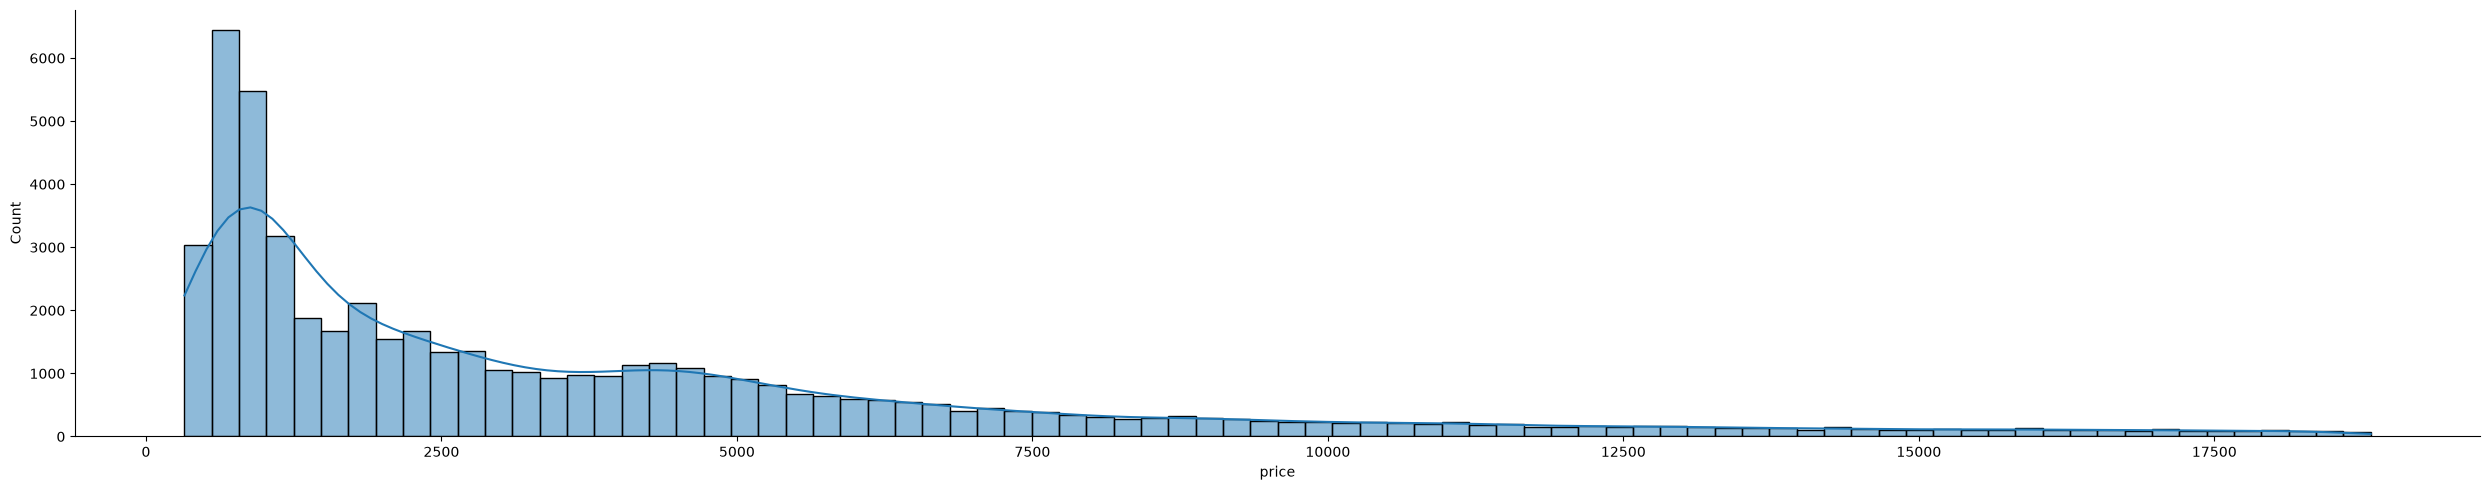

In [6]:
sns.displot(df['price'], kde=True, aspect=5);

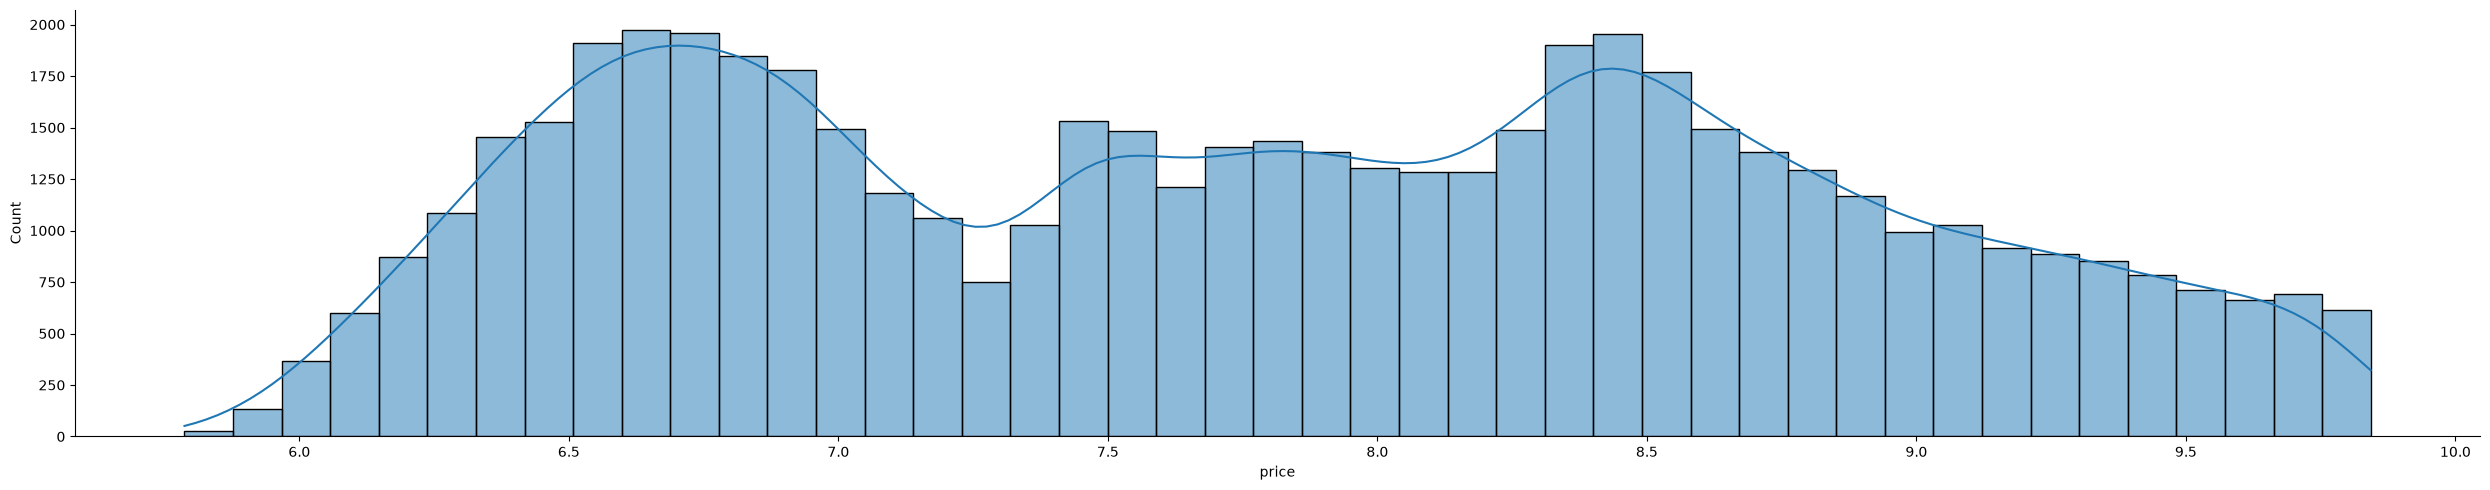

In [7]:
sns.displot(np.log(df['price']), kde=True, aspect=5);

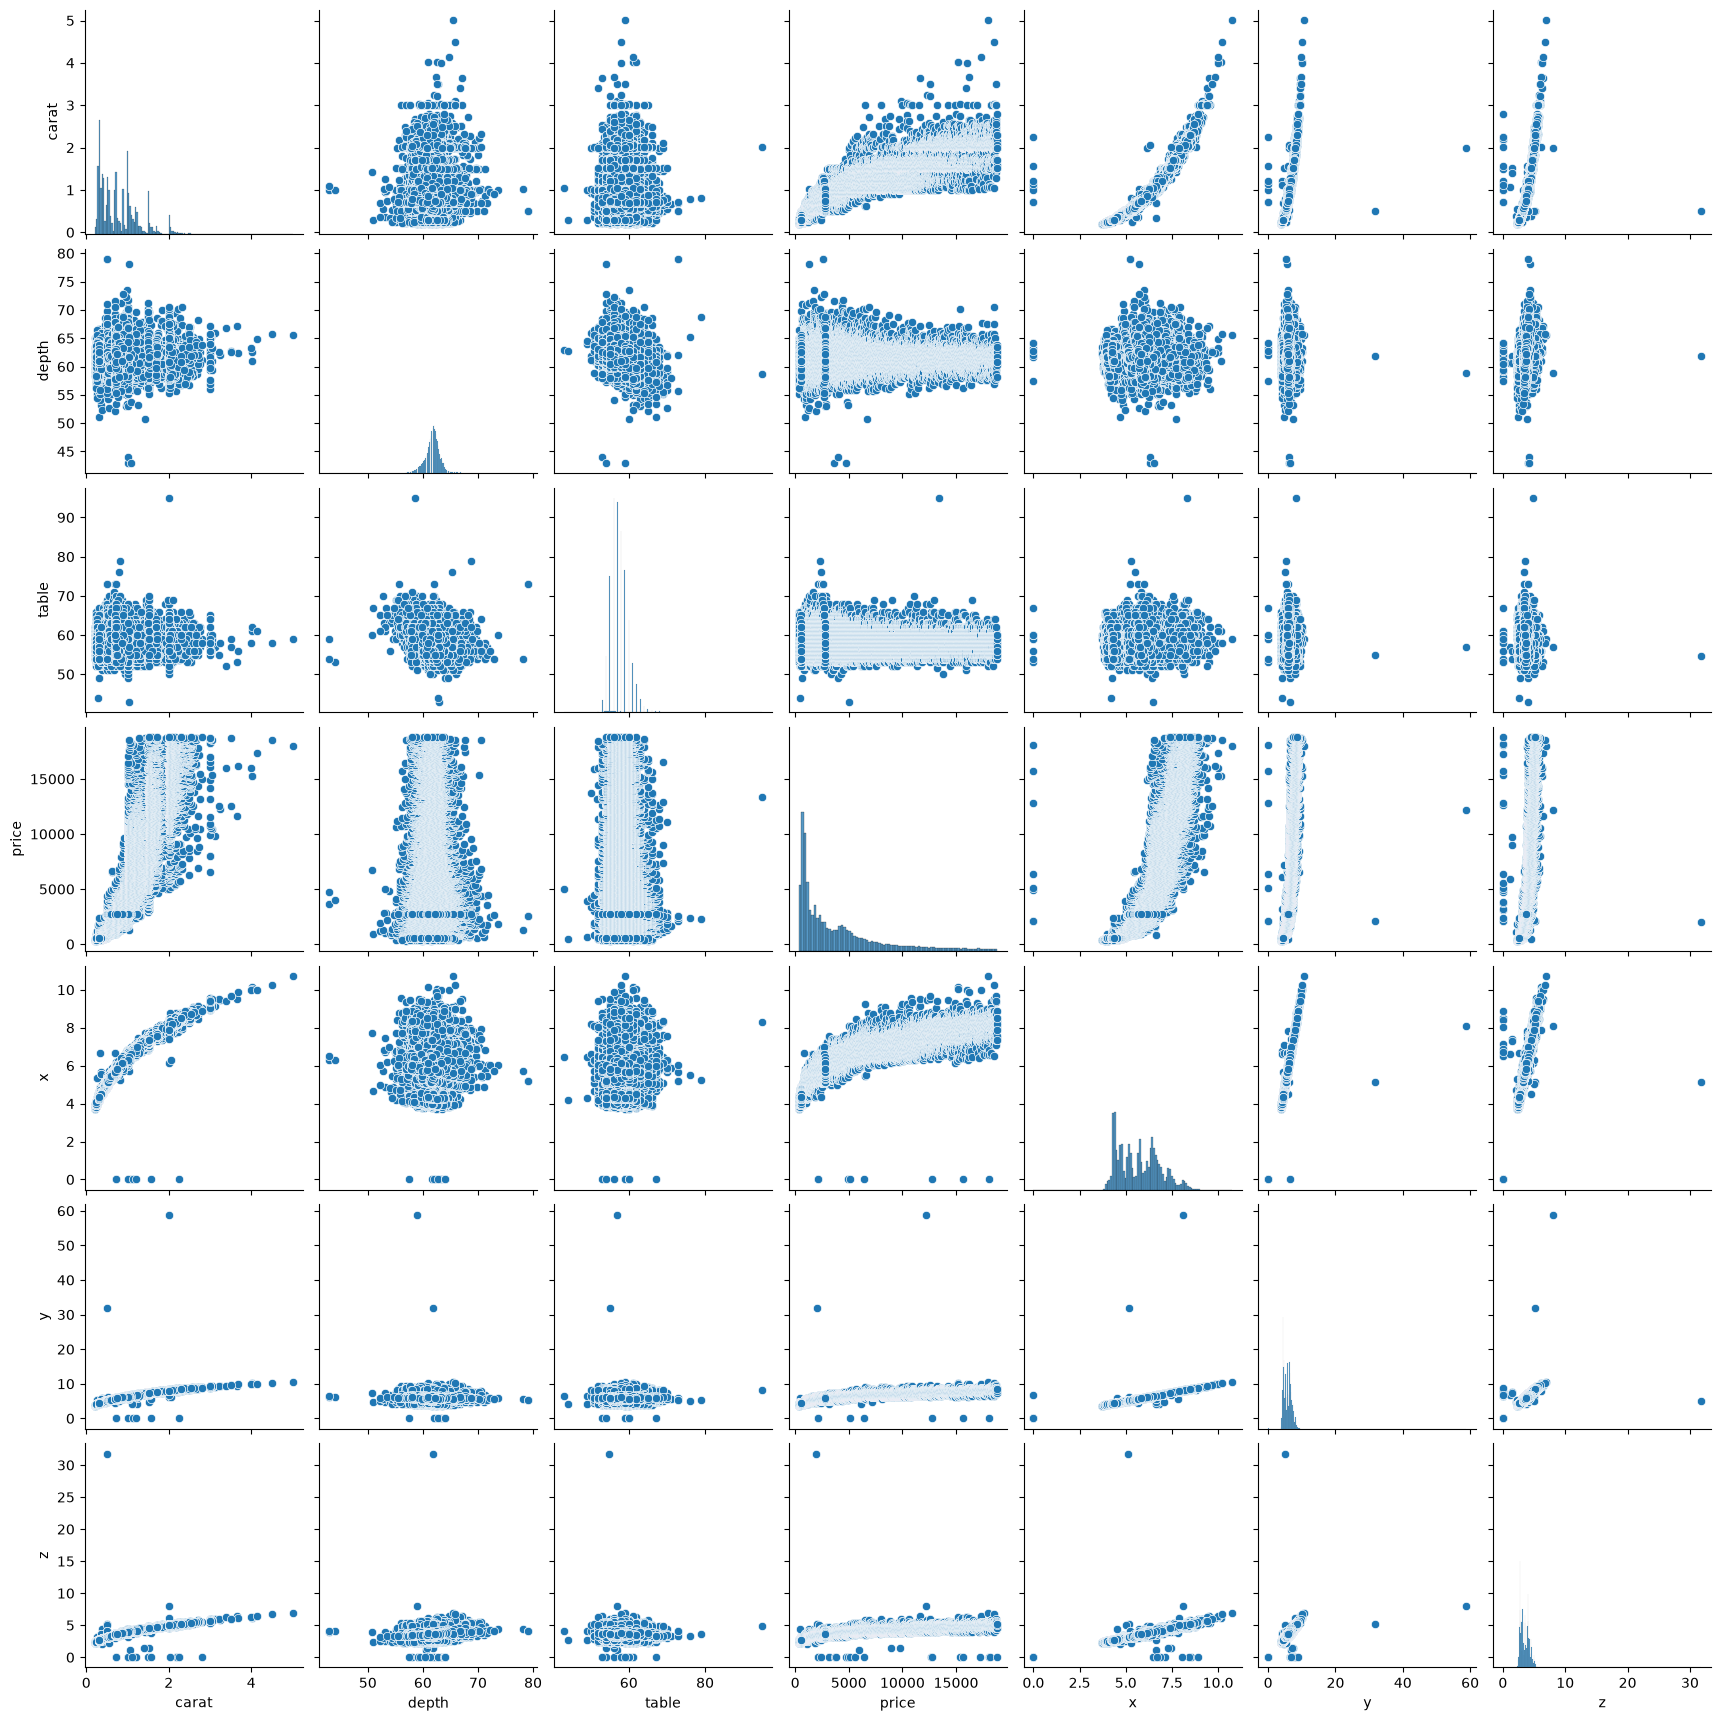

In [8]:
sns.pairplot(df);

In [9]:
df['cut'].value_counts()

cut
Ideal        21551
Premium      13791
Very Good    12082
Good          4906
Fair          1610
Name: count, dtype: int64

### Data Cleaning

In [10]:
# clean x,y,z zero values
to_drop = df[(df['x']==0)|(df['y']==0)|(df['z']==0)].index
df.drop(to_drop, inplace=True)

In [11]:
to_drop = df[(df['y']>20)| (df['z']>20)].index
df.drop(to_drop, inplace=True)

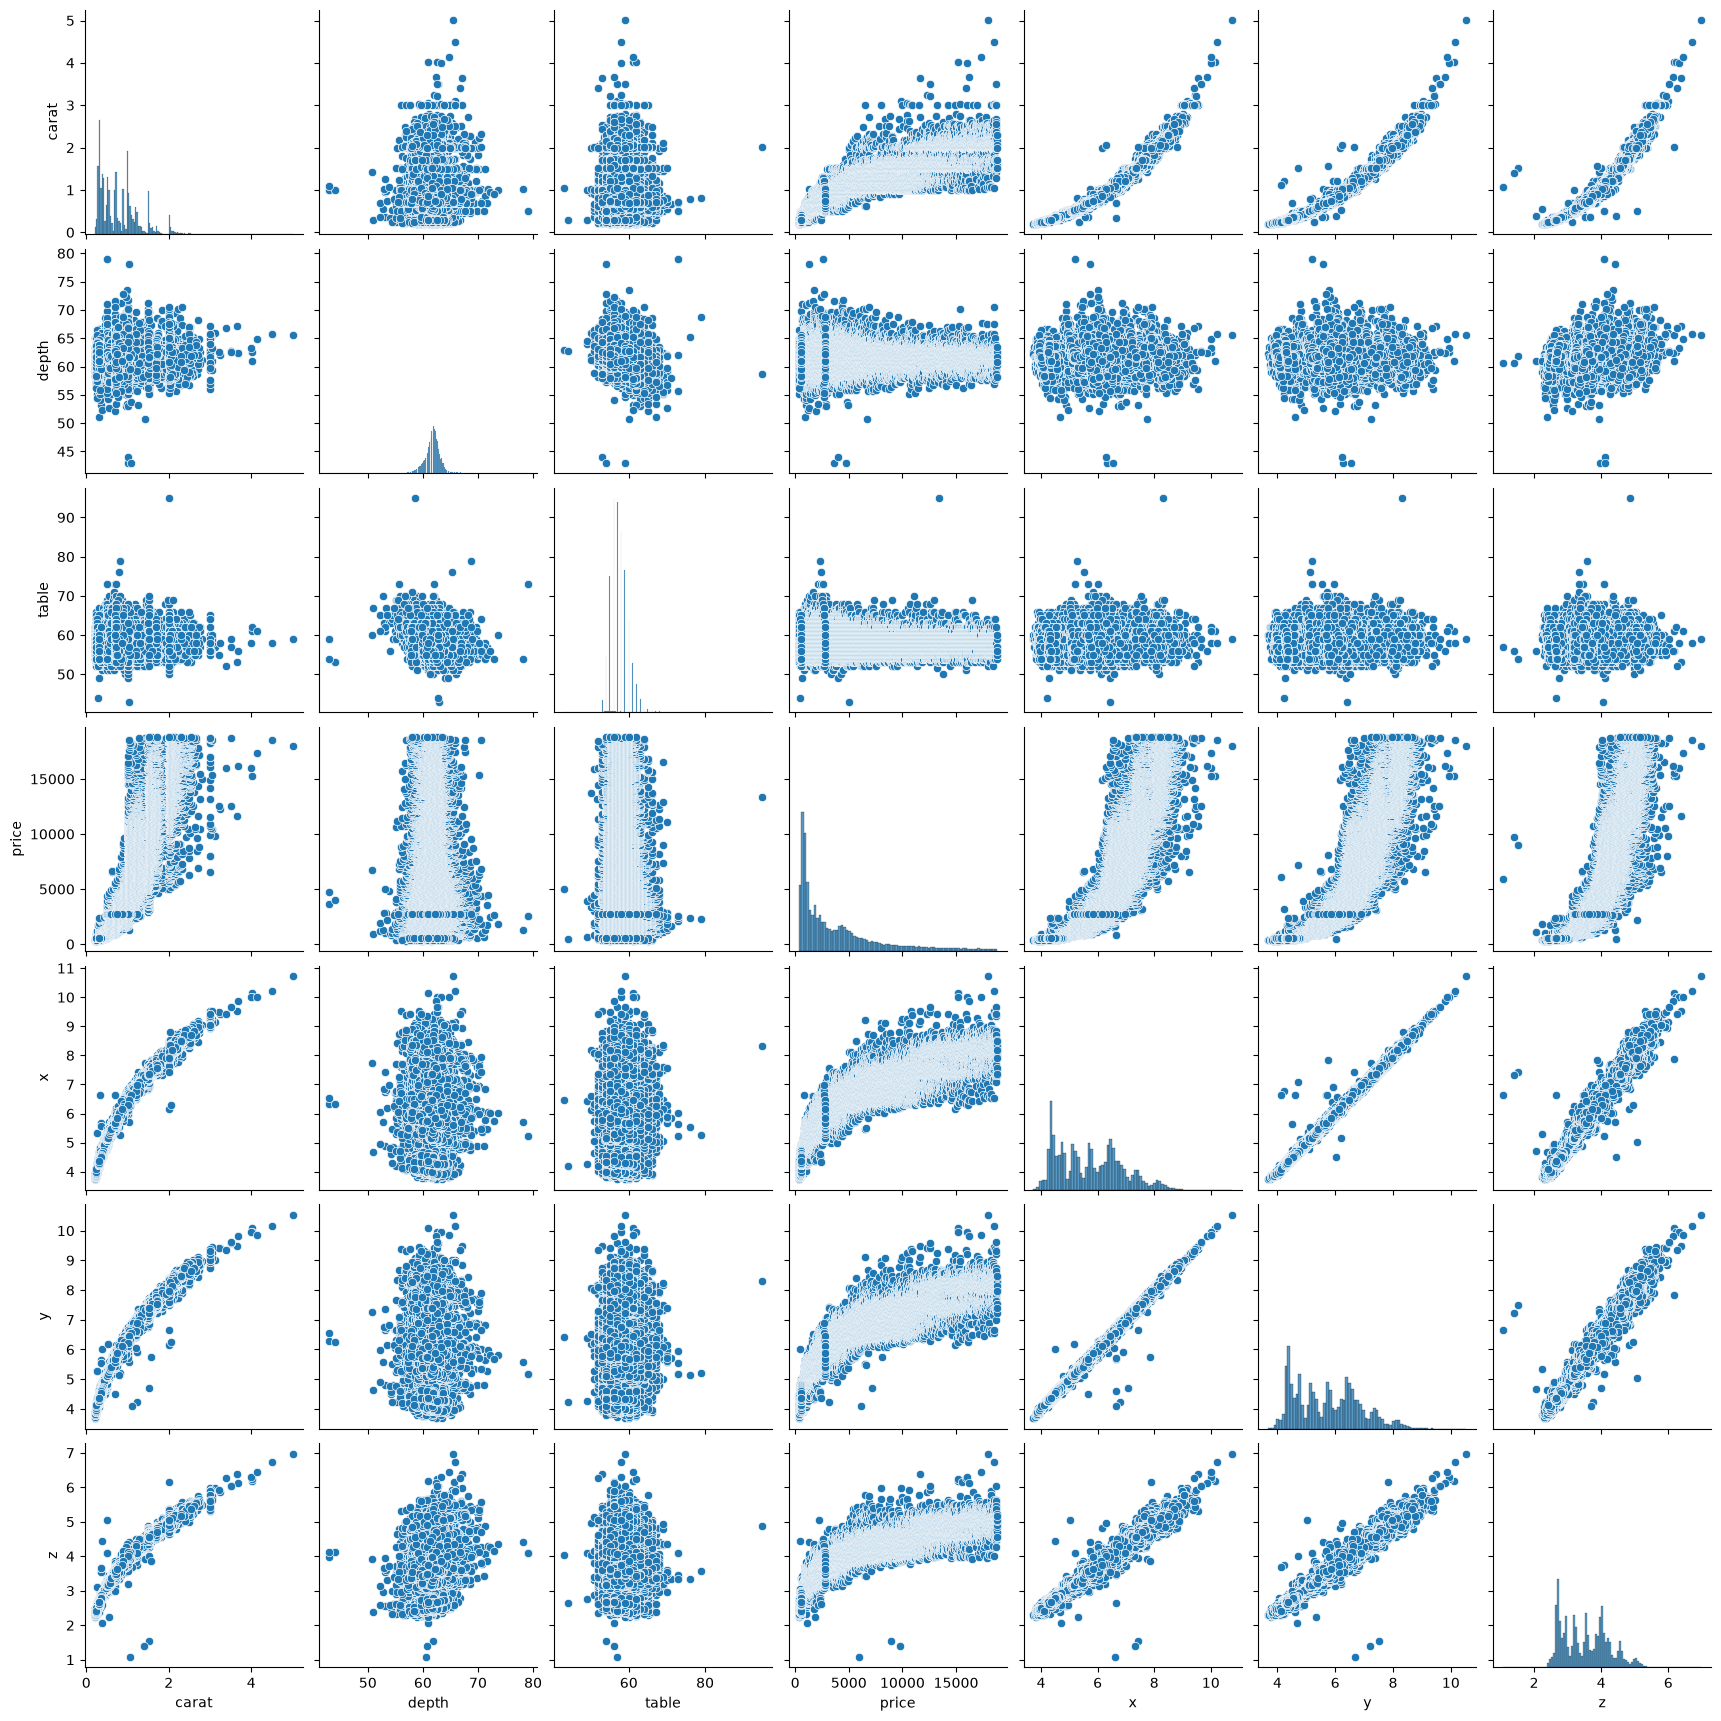

In [12]:
sns.pairplot(df);

### Feature Engineering

In [13]:
# ordinal categorical feature to numerical feature
df['cut_int'] = df['cut'].map({'Fair':1, 'Good':2, 'Very Good':3, 'Premium':4, 'Ideal':5})
df['clarity_int'] = df['clarity'].map({'I1':1, 'SI2':2, 'SI1':3, 'VS1':4, 'VS2':5, 'VVS1':6, 'VVS2':7, 'IF':8})

In [14]:
# nominal categorical feature to numerical feature
df = pd.get_dummies(df, columns=['color'], prefix='color')

In [15]:
df

,carat,cut,clarity,depth,table,price,x,y,z,cut_int,clarity_int,color_D,color_E,color_F,color_G,color_H,color_I,color_J
0,0.23,Ideal,SI2,61.5,55.0,326,3.95,3.98,2.43,5,2,False,True,False,False,False,False,False
1,0.21,Premium,SI1,59.8,61.0,326,3.89,3.84,2.31,4,3,False,True,False,False,False,False,False
2,0.23,Good,VS1,56.9,65.0,327,4.05,4.07,2.31,2,4,False,True,False,False,False,False,False
3,0.29,Premium,VS2,62.4,58.0,334,4.20,4.23,2.63,4,5,False,False,False,False,False,True,False
4,0.31,Good,SI2,63.3,58.0,335,4.34,4.35,2.75,2,2,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53935,0.72,Ideal,SI1,60.8,57.0,2757,5.75,5.76,3.50,5,3,True,False,False,False,False,False,False
53936,0.72,Good,SI1,63.1,55.0,2757,5.69,5.75,3.61,2,3,True,False,False,False,False,False,False
53937,0.70,Very Good,SI1,62.8,60.0,2757,5.66,5.68,3.56,3,3,True,False,False,False,False,False,False
53938,0.86,Premium,SI2,61.0,58.0,2757,6.15,6.12,3.74,4,2,False,False,False,False,True,False,False


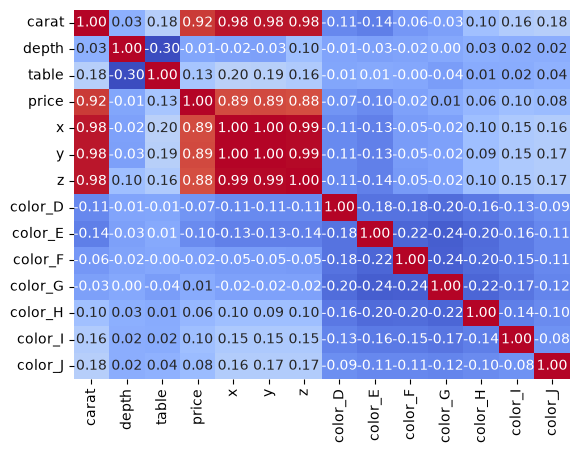

In [16]:
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", cmap='coolwarm', cbar=False);

In [17]:
X = df.drop(columns=['price', 'cut', 'clarity']) # Features
y = df['price'] # Target variable

In [18]:
X

,carat,depth,table,x,y,z,cut_int,clarity_int,color_D,color_E,color_F,color_G,color_H,color_I,color_J
0,0.23,61.5,55.0,3.95,3.98,2.43,5,2,False,True,False,False,False,False,False
1,0.21,59.8,61.0,3.89,3.84,2.31,4,3,False,True,False,False,False,False,False
2,0.23,56.9,65.0,4.05,4.07,2.31,2,4,False,True,False,False,False,False,False
3,0.29,62.4,58.0,4.20,4.23,2.63,4,5,False,False,False,False,False,True,False
4,0.31,63.3,58.0,4.34,4.35,2.75,2,2,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53935,0.72,60.8,57.0,5.75,5.76,3.50,5,3,True,False,False,False,False,False,False
53936,0.72,63.1,55.0,5.69,5.75,3.61,2,3,True,False,False,False,False,False,False
53937,0.70,62.8,60.0,5.66,5.68,3.56,3,3,True,False,False,False,False,False,False
53938,0.86,61.0,58.0,6.15,6.12,3.74,4,2,False,False,False,False,True,False,False


### Model Trainning

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(43133, 15) (10784, 15) (43133,) (10784,)


In [20]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](15,)","[11112.19, 53. , -18.32,..., -143.37, -594.36,-1477.07]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](15,)","['carat','depth','table',...,'color_H','color_I','color_J']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-3794
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,15
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(14)


In [21]:
y_pred = model.predict(X_test)

print('MSE:', mean_squared_error(y_test, y_pred))
print('MAE:', mean_absolute_error(y_test, y_pred))
print('RMSE:', np.sqrt(mean_squared_error(y_test, y_pred)))

MSE: 1384283.4735526328
MAE: 771.3041358675716
RMSE: 1176.5557672939403


In [22]:
X_test_sample = X_test[:5]
X_test_sample['actual_price'] = y_test[:5]
X_test_sample['predicted_price'] = y_pred[:5]
X_test_sample

,carat,depth,table,x,y,z,cut_int,clarity_int,color_D,color_E,color_F,color_G,color_H,color_I,color_J,actual_price,predicted_price
33878,0.30,62.1,55.0,4.33,4.30,2.68,5,5,False,True,False,False,False,False,False,844,697.858714
21091,1.22,61.2,58.0,6.85,6.90,4.21,3,4,False,False,False,True,False,False,False,9261,7545.108958
36461,0.31,61.7,59.0,4.34,4.31,2.67,4,5,True,False,False,False,False,False,False,942,817.166833
40257,0.40,60.8,55.0,4.82,4.79,2.92,5,7,False,False,False,False,True,False,False,1125,1534.622452
1632,0.70,62.7,57.0,5.65,5.70,3.56,5,4,False,True,False,False,False,False,False,3016,3399.547969


In [23]:
model.coef_, model.intercept_

(array([11112.18934355,    53.00075526,   -18.32002068, -2229.51179902,
         2615.48305584, -2294.81342878,   133.59227562,   437.6317801 ,
          785.27339974,   575.82236011,   517.18699633,   336.51381599,
         -143.36610753,  -594.35975883, -1477.07070581]),
 np.float64(-3794.1775535168576))

linernear regression model equation
$$
y = w_1x_1 + w_2x_2 + w_3x_3 + ... + w_nx_n + b
$$

In [24]:
w1, w2, w3, w4, w5, w6, w7, w8, w9, w10, w11, w12, w13, w14, w15 = model.coef_
b = model.intercept_
# 0.30	62.1	55.0	4.33	4.30	2.68	5	5	False	True	False	False	False	False	False	
w1*0.30 + w2*62.1 + w3*55.0 + w4*4.33 + w5*4.30 + w6*2.68 + w7*5 + w8*5 + w9*0 + w10*1 + w11*0 + w12*0 + w11*0 + w12*0 + b

np.float64(697.8587136385654)

### Evaluation

* $y_i$ — the true value
* $\hat{y}_i$ — the predicted value
* $\bar{y}$ — the mean of the true \(y\) values
* $n$ — the number of observations

**MSE** — Mean Squared Error
$$
MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
$$
**RMSE** — Root Mean Squared Error
$$
RMSE = \sqrt{MSE}
$$
or explicitly:
$$
RMSE = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2}
$$
**MAE** — Mean Absolute Error
$$
MAE = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|
$$
**MAPE** — Mean Absolute Percentage Error
$$
MAPE = \frac{1}{n} \sum_{i=1}^{n}
\left|
\frac{y_i - \hat{y}_i}{y_i}
\right|
\times 100\%
$$
**R²** — Coefficient of Determination
$$
R^2 =
1 -
\frac{
\sum_{i=1}^{n}(y_i-\hat{y}_i)^2
}{
\sum_{i=1}^{n}(y_i-\bar{y})^2
}
$$


In [25]:
y_true = np.array( [1,  10, 10,  1,  -10, 1,  10, 1, 5, 10])
y_pred1 = np.array([3,  13, 13,  3,  -13, -3, 14, 3, 1, 13]) # result of model 1
y_pred2 = np.array([1,  1,  9,  -1,  -20, 1,  9,  1, 4, 11 ]) # result of model 2
y_pred3 = np.array(y_true.shape[0]*[y_true.mean()]) # result of model 3

def r2_score(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - (ss_res / ss_tot)

def mape(y_true, y_pred):
    mask = y_true != 0
    return np.mean(
        np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])
    ) * 100

# calc MSE - Mean Squared Error
mse1 = np.mean((y_true - y_pred1) ** 2)
mse2 = np.mean((y_true - y_pred2) ** 2)
print(f"MSE1: {mse1:.2f}")
print(f"MSE2: {mse2:.2f}")
# calc MAE - Mean Absolute Error
mae1 = np.mean(np.abs(y_true - y_pred1))
mae2 = np.mean(np.abs(y_true - y_pred2))
print(f"MAE1: {mae1:.2f}")
print(f"MAE2: {mae2:.2f}")
# calc MAPE - Mean Absolute Percentage Error
mape1 = mape(y_true, y_pred1)
mape2 = mape(y_true, y_pred2)
print(f"MAPE1: {mape1:.2f}%")
print(f"MAPE2: {mape2:.2f}%")
# calc RMSE - Root Mean Squared Error
rmse1 = np.sqrt(np.mean((y_true - y_pred1) ** 2))
rmse2 = np.sqrt(np.mean((y_true - y_pred2) ** 2))
print(f"RMSE1: {rmse1:.2f}")
print(f"RMSE2: {rmse2:.2f}")
# calc R2 - R-squared
r2_1 = r2_score(y_true, y_pred1)
r2_2 = r2_score(y_true, y_pred2)
r2_3 = r2_score(y_true, y_pred3)
print(f"R2_1: {r2_1:.2f}")
print(f"R2_2: {r2_2:.2f}")
print(f"R2_3: {r2_3:.2f}")


MSE1: 9.60
MSE2: 18.90
MAE1: 3.00
MAE2: 2.50
MAPE1: 124.00%
MAPE2: 44.00%
RMSE1: 3.10
RMSE2: 4.35
R2_1: 0.75
R2_2: 0.50
R2_3: 0.00


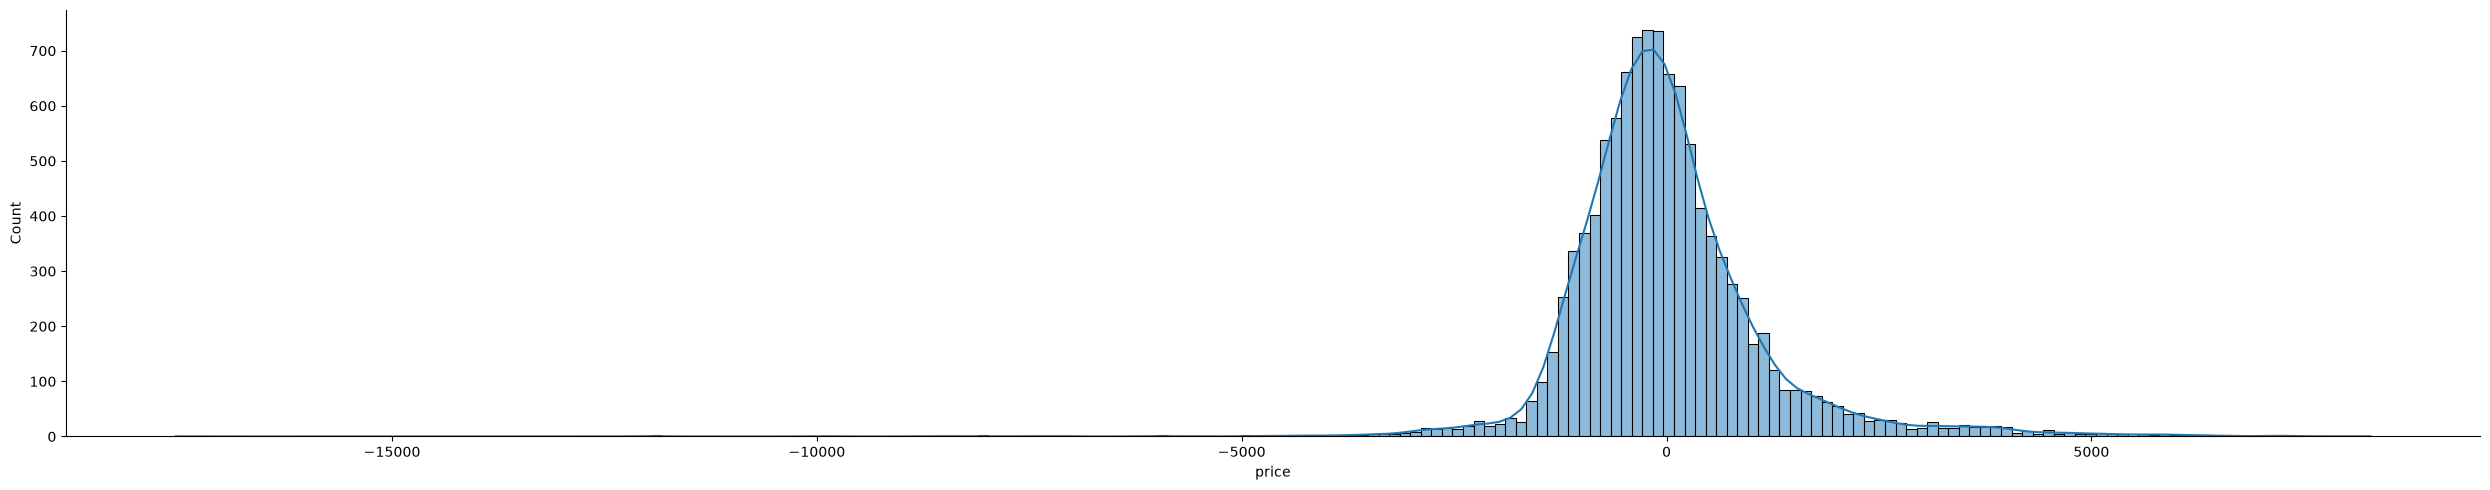

In [26]:
sns.displot(y_test - y_pred, kde=True, aspect=5);